# Tutorial 3: Decoding the Surface Code

In Notebook 1, we decoded Shor’s code by looking up a correction for each syndrome. In Notebook 2, we built rotated surface-code patches and used lattice surgery to perform logical operations. When we added noise, we saw detector events and raw logical failures, but we did not use the detector events to correct the results.

We now want to use that measurement record. Our running example is a noisy logical CNOT. Its checks are measured over several rounds, and the check pattern changes as patches merge and split. A fault may affect the data, a check report, or both. Each leaves a pattern of detector events. The decoding problem is to use that pattern to decide whether the logical result needs to be changed.

We will start by following a few faults through the CNOT and seeing which events they produce. From these examples, we will build a simple decoder for likely single-fault patterns and test how often it corrects the logical result. We will then examine TQEC’s spacetime description of the CNOT and compare our decoder with PyMatching on samples from the same circuit and noise model. The cases our decoder gets wrong will show what it needs to handle beyond single faults.

## 1. Build a logical CNOT with TQEC

In Notebook 2, we described a lattice-surgery CNOT as three logical measurements: $Z_CZ_A$, then $X_AX_D$, then $Z_A$, where $A$ is an auxiliary logical patch. TQEC gives us a ready-made construction of this CNOT, so we do not need to place every patch and specify every check by hand.

TQEC represents the operation as a **BlockGraph**. Its cubes describe regions of a protected logical computation, and its pipes connect those regions across space or time. Through the block graphs, we can see how the patches are joined and separated. In this picture, the geometric $z$ direction represents **time**.

We use TQEC’s built-in logical CNOT. `cnot(Basis.Z)` returns a spacetime `BlockGraph` with logical $Z$-basis inputs and outputs. 

In [11]:
from pathlib import Path
import webbrowser
from tqec import Basis
from tqec.gallery import cnot

# Build the CNOT block graph
cnot_graph = cnot(Basis.Z)

# Save and open its interactive 3D viewer
viewer_path = Path("cnot_view.html").resolve()
cnot_graph.view_as_html(write_html_filepath=viewer_path)
vis = webbrowser.open(viewer_path.as_uri())

### Reading the CNOT BlockGraph

Read the graph **from bottom to top**: height represents time. The tall column on the left follows the control patch $C$ from input to output. The tall column on the right follows the target patch $D$. The shorter column in the middle is the ancillary patch $A$, which participates in the two joint measurements.

Each block stands for a region of the protected computation, not a single qubit or gate. Compiling the graph at a chosen code distance produces the physical circuit, including repeated check measurements. 
In our example, TQEC expands this CNOT BlockGraph into four successive regions of **three check-measurement rounds each** (we can also specify the number of rounds when compiling the circuit). The detector plot therefore has time coordinates 0 through 11:

- **Times 0–2:** prepare the control and target patches and begin measuring their checks.
- **Times 3–5:** introduce the ancilla and perform the first joint measurement, $\bar Z_C\bar Z_A$.
- **Times 6–8:** perform the second joint measurement, $\bar X_A\bar X_D$.
- **Times 9–11:** continue checking the separated output patches before final readout.

The **lower connection** joins $C$ to $A$ first, for the logical $ZZ$ measurement. Farther up in time, the **upper connection** joins $A$ to $D$ for the logical $XX$ measurement. The ancilla is then read out. The measurement outcomes determine a known CNOT byproduct, which we can track in the Pauli frame.

Red faces are $X$-type boundaries, and blue faces are $Z$-type boundaries. The intersections 
of blocks label the boundary being joined, not the logical operator being measured. In this first connection, TQEC joins the control and ancilla at $X$-type boundary faces.

<img src="assets/blockgraph_cnot.png" alt="CNOT BlockGraph" width="320">

### Choose a logical observable

The BlockGraph shows the shape of the CNOT, but we also need to specify what logical information to track through it. 
TQEC calls this a **correlation surface**. 
It connects logical operators at the inputs and outputs through the surgery operation.

For our `cnot(Basis.Z)` graph, TQEC returns two surfaces:
1. correlation_surfaces[0] tracks the control’s logical $Z$: $\bar Z_C^{\mathrm{in}} \rightarrow \bar Z_C^{\mathrm{out}}$. The CNOT leaves this operator unchanged.
2. correlation_surfaces[1] tracks the target’s logical $Z$: $\bar Z_D^{\mathrm{in}} \rightarrow \bar Z_C^{\mathrm{out}}\bar Z_D^{\mathrm{out}}$. This surface branches through the interaction between the patches, showing the nontrivial action of the CNOT.

This graph has two independent $Z$-basis correlation surfaces. We will display one now and use it as the observable in our later Stim circuit. The highlighted surface represents a logical measurement relationship, not an error.

In [15]:
# Find the logical observables supported by this CNOT graph.
correlation_surfaces = cnot_graph.find_correlation_surfaces()
print(f"Number of correlation surfaces: {len(correlation_surfaces)}")

# Choose the surface that passes through the interaction between the patches.
chosen_surface = correlation_surfaces[1]  # This is the branching surface shown in figure (b).

# Save a viewer with that surface highlighted.
surface_viewer_path = Path("cnot_correlation_surface.html").resolve()
cnot_graph.view_as_html(
    write_html_filepath=surface_viewer_path,
    pop_faces_at_directions=("-Y",),  # Open one side so the surface is visible.
    show_correlation_surface=chosen_surface,
)
vis = webbrowser.open(surface_viewer_path.as_uri())

Number of correlation surfaces: 2


### Reading the correlation surface
<table>
  <tr>
    <td align="center">
      <img src="assets/correlation_surface0.png" alt="Control Z correlation surface" width="263">
    </td>
    <td align="center">
      <img src="assets/correlation_surface1.png" alt="Branching Z correlation surface" width="280">
    </td>
  </tr>
  <tr>
    <td align="center"><b>(a)</b> Control Z</td>
    <td align="center"><b>(b)</b> Target Z through the CNOT</td>
  </tr>
</table>


The deep blue overlay is the selected logical $Z$ correlation surface.
 In **(a)**, the surface [0] connects $\bar Z_C^{\mathrm{in}}$ to $\bar Z_C^{\mathrm{out}}$. In **(b)**, [1] connects $\bar Z_D^{\mathrm{in}}$ to both $\bar Z_C^{\mathrm{out}}$ and $\bar Z_D^{\mathrm{out}}$.

### Compile the CNOT into a circuit

When defining a patch, TQEC uses a size-scaling parameter $k$ and sets the spatial code distance through
$$
d = 2k+1.
$$
By default, the number of check rounds per time block also equals $2k+1$. Increasing $k$ therefore increases both patch size and duration.
We can also change the duration by changing the `block_temporal_height` in `compile_block_graph()`.

We add circuit-level noise with physical error parameter $p=0.001$. This model includes faults during gates, preparation, measurement, and idle periods. 
Finally, `n_shots = 2_000` tells Stim to repeat this entire noisy, 12-round circuit 2,000 independent times. It does not change how many check rounds occur within one shot.

In [59]:
from tqec import NoiseModel, compile_block_graph

k = 1                         # d = 2k + 1 = 3
physical_error_rate = 0.001

# Turn the logical BlockGraph into a distance-three physical circuit.
compiled_cnot = compile_block_graph(
    cnot_graph,
    observables=[chosen_surface],
)
noisy_cnot_circuit = compiled_cnot.generate_stim_circuit(
    k=k,
    noise_model=NoiseModel.uniform_depolarizing(physical_error_rate),
    do_not_use_database=True,  # Avoid writing TQEC's detector cache to disk.
)

print(f"Physical qubits: {noisy_cnot_circuit.num_qubits}")
print(f"Detectors: {noisy_cnot_circuit.num_detectors}")
print(f"Logical observables: {noisy_cnot_circuit.num_observables}")

Physical qubits: 81
Detectors: 256
Logical observables: 1


### Count the number of detectors

A **detector** is a parity check on a specified set of measurement reports
whose combined parity is predictable when there are no faults.
A **detection event** occurs when the reported parity differs from that
expected value.

For an unchanged stabilizer measured in consecutive rounds, the reports
should agree. Its detector bit is therefore

$$
d_i(t)=s_i(t)\oplus s_i(t-1),
$$

where $s_i(t)$ is the reported bit for stabilizer $i$ in round $t$.
Here, $d_i(t)=1$ means a detection event occurred. Preparation, surgery
transitions, and final readout can require relations involving different
sets of measurement reports.

Our circuit contains **256 detector definitions**, distributed across
12 time coordinates. Each shot evaluates all 256 relations. 

A separate distance-three patch has
$$
d^2 - 1 = 8
$$
stabilizer checks: 4 $X$ checks and 4 $Z$ checks, 2 weight-4 and 2 boundary weight-2 each.
Initially and finally, the circuit has two separate patches, giving 
$$
8+8=16
$$
check reports per round.

During the two surgery stages, the merged region contains
$$
9(C) + 3(\mathrm{bridge}) + 9(A)=21
$$
data qubits. 

After measuring the joint parity, the region encodes one remaining logical degree of freedom with $21-1=20$ independent stabilizer checks. In this circuit, these are $8 X$ checks and $12 Z$ checks.
Meanwhile, $D$ remains separate and continue its eight checks:
$$
\underbrace{20}_{C\text{ merged with }A}
+
\underbrace{8}_{D}
=
\boxed{28\text{ reports per round}}.
$$
Similar reasoning applies to the second surgery stage. Therefore,
$$
3(16)+3(28)+3(28)+3(16)=\boxed{264}
$$
stabilizer-check reports.

Usually, a check report gives a detector by comparison with the previous report. But newly introduced checks can have unknown initial signs.
In this circuit:
- Round 0: eight first X-check reports are not predictable from the Z-basis preparation.
- Round 3: eight newly introduced Z-check reports (4 seam + 4 on A) do not yet supply deterministic detector relations.
- Round 6: four newly introduced X-check (seam, A in X-basis) reports do not yet supply deterministic detector relations.
So we subtract
$$
8+8+4=20.
$$

Moreover, we need extra detectors to check whether the final data readouts agree with the last Z-check reports.
For a distance-three patch, even though a logical Z only requires $z_0\oplus z_1\oplus z_2$, we physically measure all night data qubits. From those nine readouts, we also calculate the parities of its four Z stabilizers. Each is compared with its last check report:
$$
d_j=s_j^{\mathrm{last}}
\oplus
\bigoplus_{i\in\mathrm{support}(S_j)}z_i,
\qquad j=1,2,3,4,
$$
where $z$ is the data readout, $s$ is the last reported stabilizer measurement before reading out the data, $d$ is the detector bit. That gives four additional detectors, one per Z-check history.

- **Round 8:** reading out the ancillary region closes four Z-check histories.
- **Round 11:** reading out $C$ and $D$ closes four Z-check histories per patch.

Together, these supply $4+8=12$ additional detectors without requiring
extra stabilizer measurements.

Finally, we derive the number of detectors by couting check reports, removing the ones that cannot yet define a detector, then adding readout relations:
$$
\boxed{256=264-20+12}.
$$


Shot 0: 4 detection events
Fired detectors: ['D85', 'D88', 'D213', 'D231']
Logical observable L0 flipped before decoding: False
Uncorrected L0 flip rate: 30.1%


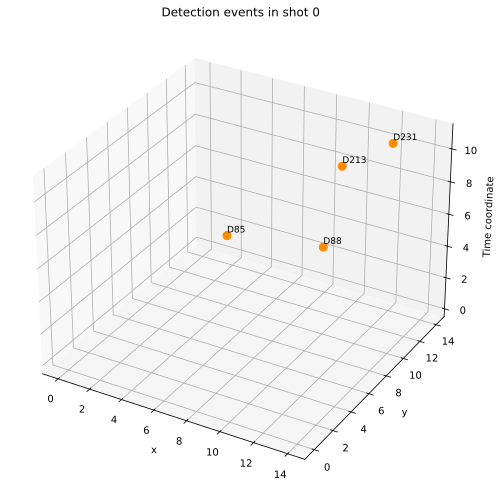

In [63]:
import numpy as np
import matplotlib.pyplot as plt

n_shots = 2_000

# Generate fresh samples each time this cell runs.
detector_events, observable_flips = (
    noisy_cnot_circuit.compile_detector_sampler().sample(
        shots=n_shots,
        separate_observables=True,
    )
)

# Inspect the first shot.
shot_id = 0
fired_ids = np.flatnonzero(detector_events[shot_id])
coordinates = noisy_cnot_circuit.get_detector_coordinates()

print(f"Shot {shot_id}: {len(fired_ids)} detection events")
print("Fired detectors:", [f"D{i}" for i in fired_ids])
print(
    "Logical observable L0 flipped before decoding:",
    bool(observable_flips[shot_id, 0]),
)
print(f"Uncorrected L0 flip rate: {observable_flips[:, 0].mean():.1%}")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot only the detectors that fired, without depth-dependent fading.
if len(fired_ids):
    fired_positions = np.array([
        coordinates[int(i)][:3] for i in fired_ids
    ])

    ax.scatter(
        *fired_positions.T,
        color="darkorange",
        s=65,
        depthshade=False,
    )

    # Label each event with its detector ID.
    for detector_id, (x, y, t) in zip(fired_ids, fired_positions):
        ax.text(x, y, t + 0.2, f"D{detector_id}", fontsize=9)
else:
    ax.text2D(
        0.5, 0.5, "No detection events",
        transform=ax.transAxes,
        ha="center",
    )

# Preserve the full circuit's coordinate range without plotting gray dots.
all_positions = np.array([
    coordinates[i][:3]
    for i in range(noisy_cnot_circuit.num_detectors)
])
ax.set_xlim(all_positions[:, 0].min() - 1, all_positions[:, 0].max() + 1)
ax.set_ylim(all_positions[:, 1].min() - 1, all_positions[:, 1].max() + 1)
ax.set_zlim(all_positions[:, 2].min() - 0.5, all_positions[:, 2].max() + 0.5)

ax.set(xlabel="x", ylabel="y", zlabel="Time coordinate")
ax.set_title(f"Detection events in shot {shot_id}")
plt.tight_layout()
plt.show()

## 2. Decode the noisy CNOT

**PyMatching** is a decoder library that implements minimum-weight perfect matching. It turns the DEM into a graph. Each edge connects two detectors, or
one detector to a boundary. 
However, a single circuit fault can trigger more than two detectors. 
We therefore request `decompose_errors=True` when generating the DEM.
This asks Stim to decompose such effects into components involving at most
two detectors, where possible. For example,

`error(p) D0 D1 D2 D3`

might become

`error(p) D0 D1 ^ D2 D3`.

The `^` separates components belonging to the same mechanism. They can be
drawn as two graph edges, although they remain correlated. Ordinary matching
treats these components separately, so it does not fully use that correlation.

This decomposition changes the representation used for decoding.
It does not change the circuit or the noise we sampled.

### Reading a sequence of detector events

For a check that stays in place, let $s_t$ be its reported result in round $t$. A detector compares consecutive reports:

$$
d_t=s_t\oplus s_{t-1}.
$$

A `1` in the **detector record** means the report changed. It does not mean “an error is present in this round.” In the examples below, assume the check was known to report `0` before the first round:

- **Detector events `110` → check reports `100`.** The report changed to `1`, then immediately returned to `0`. One possible cause is a wrong check readout in the first round. Two dots do not necessarily mean two physical faults.
- **Detector events `101` → check reports `110`.** The report stayed changed for two rounds before returning. A data fault followed by another change that reversed the effect of the former could cause this. Two faulty readouts could also produce the same record.
- **Detector events `100` → check reports `111`.** The report changed once and stayed at `1` throughout the rounds shown. A persistent data error is one possible explanation. The absence of another dot only tells us that this check did not change again *within this record*.

These are possible explanations, not diagnoses. The decoder also considers events at nearby checks, where the record begins and ends, and which faults the circuit allows. During a CNOT merge or split, some detectors combine several measurement results rather than just two consecutive reports.

### From the circuit to a detector error model

The orange points are detector events observed in one shot. To explain them, the decoder needs a model of what faults could produce these events.

Stim generates a detector error model (DEM) from the noisy circuit. Each entry describes a possible fault mechanism, its probability, and its effects on detectors and tracked logical observables.

For example, 

error(0.001) D4 D7 L0 

describes a mechanism that occurs with probability $0.001$ and flips detectors D4 and D7 and logical observable L0. If this mechanism occurred alone, those two detectors would fire. Several physical faults can contribute to the same entry when they have the same detector and tracked logical effects, with their probabilities combined accordingly.

More than one mechanism may occur in one shot, and their detector and logical effects combine by parity: two flips of the same detector or observable cancel. The decoder therefore uses the probabilities to choose a likely combination of entries that explains the observed detector events. It then combines their logical effects to predict whether the logical readout needs to be flipped.

In [50]:
# Analyze the noisy CNOT circuit without sampling another shot.
detector_error_model = noisy_cnot_circuit.detector_error_model()

# Display a few possible error mechanisms.
# These are model entries, not faults identified in our plotted shot.
error_entries = [
    instruction
    for instruction in detector_error_model.flattened()
    if instruction.type == "error"
]

print(f"Detectors in the model: {detector_error_model.num_detectors}")
print(f"Logical observables in the model: {detector_error_model.num_observables}")
print(f"Error mechanisms in the model: {len(error_entries)}")
print("\nExample mechanisms:")
for entry in error_entries[:4]:
    print(entry)

Detectors in the model: 256
Logical observables in the model: 1
Error mechanisms in the model: 3466

Example mechanisms:
error(0.0012662) D0
error(0.00259527) D0 D6 L0
error(0.00451643) D0 D19
error(0.00292699) D1


## 2. Decode the noisy CNOT

**PyMatching** is a decoder library that implements minimum-weight perfect matching. It turns the DEM into a graph. Each edge connects two detectors, or
one detector to a boundary. 
However, a single circuit fault can trigger more than two detectors. 
We therefore request `decompose_errors=True` when generating the DEM.
This asks Stim to decompose such effects into components involving at most
two detectors, where possible. For example,

`error(p) D0 D1 D2 D3`

might become

`error(p) D0 D1 ^ D2 D3`.

The `^` separates components belonging to the same mechanism. They can be
drawn as two graph edges, although they remain correlated. Ordinary matching
treats these components separately, so it does not fully use that correlation.

This decomposition changes the representation used for decoding.
It does not change the circuit or the noise we sampled.

### Follow the detection events in one shot
Each row below identifies a detector that fired. The detector ID connects
this event to entries in the DEM and nodes in the matching graph.

The coordinates locate the detector relation in space and time. They do
not identify the physical qubit that suffered an error. An event means
that the parity of the measurements defining that detector differed from
its expected value.

In [47]:
# Reuse the selected shot without sampling again.
fired_ids = np.flatnonzero(detector_events[shot_id])
coordinates = noisy_cnot_circuit.get_detector_coordinates()

print(f"Shot {shot_id}: {len(fired_ids)} detection events\n")
print(f"{'Detector':<12}{'x':>8}{'y':>8}{'time':>8}")
print("-" * 36)

for detector_id in fired_ids:
    coords = coordinates.get(int(detector_id), [])

    # Our TQEC circuit uses the first three coordinates as x, y, time.
    # Show a dash if a coordinate is unavailable.
    values = [
        f"{coords[i]:g}" if i < len(coords) else "—"
        for i in range(3)
    ]
    print(
        f"{'D' + str(detector_id):<12}"
        f"{values[0]:>8}{values[1]:>8}{values[2]:>8}"
    )

Shot 0: 8 detection events

Detector           x       y    time
------------------------------------
D33               10      10       2
D36                8      12       2
D45                2       2       3
D47                0       4       3
D57               10      12       3
D67                2       4       4
D246              10       8      11
D247              10      10      11


In [48]:
import pymatching

# Ask Stim for a graph-like form of the circuit's error model.
matching_model = noisy_cnot_circuit.detector_error_model(
    decompose_errors=True
)

# Build the matching graph and its weights from the model.
decoder = pymatching.Matching.from_detector_error_model(matching_model)

# Decode using only the detector events observed in each shot.
predicted_flips = decoder.decode_batch(detector_events)

# Stim's logical-flip samples are used only to evaluate the decoder.
raw_failure_rate = observable_flips[:, 0].mean()
decoded_failure_rate = np.mean(
    predicted_flips[:, 0] != observable_flips[:, 0]
)

print(f"Shot {shot_id}:")
print(f"  Fired detectors: {np.flatnonzero(detector_events[shot_id])}")
print(f"  Predicted L0 flip: {int(predicted_flips[shot_id, 0])}")
print(f"  Actual L0 flip:    {int(observable_flips[shot_id, 0])}")
print()
print(f"No correction: {raw_failure_rate:.1%} logical failures")
print(f"After decoding: {decoded_failure_rate:.1%} logical failures")

Shot 0:
  Fired detectors: [ 33  36  45  47  57  67 246 247]
  Predicted L0 flip: 1
  Actual L0 flip:    1

No correction: 26.9% logical failures
After decoding: 2.5% logical failures
